In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

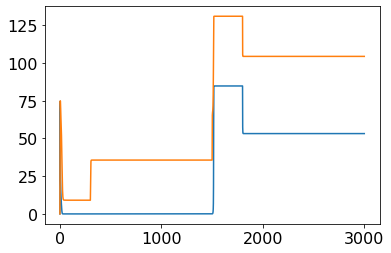

[[9.94085134e-03 3.56421290e+01]
 [5.32526800e+01 1.04429299e+02]]


In [291]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

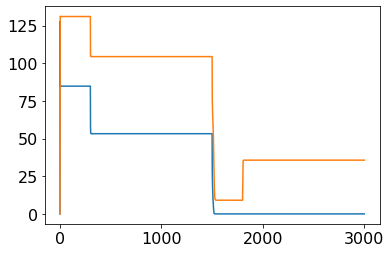

In [292]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2] * 0.99  

In [293]:
max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [294]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

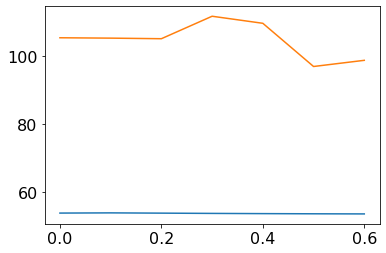

In [295]:
dur = 0.6
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

# no delay
aln.params.signalV = 0.
aln.params.de = 0.2
aln.params.di = 0.3

setinitvars(high_state_vars)

control0 = aln.getZeroControl()

#control0[:,0,2] += 1.
#control0[:,0,4] -= 3.

control0[:,1,2] += 1.
control0[:,1,4] -= 1.5

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

set cost params
RUN  0 , total integrated cost =  8.472568532657641
test control change smaller than tolerance, return zero step
RUN  1 , total integrated cost =  2.6373845993006473
test control change smaller than tolerance, return zero step
RUN  2 , total integrated cost =  1.8119909681961197
test control change smaller than tolerance, return zero step
RUN  3 , total integrated cost =  1.5420952764362137
test control change smaller than tolerance, return zero step
RUN  4 , total integrated cost =  1.3656948405035219
test control change smaller than tolerance, return zero step
RUN  5 , total integrated cost =  1.2648136374853092
test control change smaller than tolerance, return zero step
RUN  6 , total integrated cost =  1.221496688105287
test control change smaller than tolerance, return zero step
RUN  7 , total integrated cost =  1.195303363397741
test control change smaller than tolerance, return zero step
RUN  8 , total integrated cost =  1.1703341881322082
test control change sm

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  1.1442512206700095
test control change smaller than tolerance, return zero step
test control change smaller than tolerance, return zero step
RUN  16 , total integrated cost =  1.1442512206700057
Control only changes marginally.
Improved over  16  iterations by  86.49463599781492  percent.
Problem in initial value trasfer:  Vmean_exc -56.70425107701604 -56.70423253184756
[[[ 0.         -2.4241808  -1.7270211  -1.15929195 -0.70134315
   -0.32414209  0.        ]
  [ 0.          2.08230549  1.65613646  2.87999159  0.42327437
   -0.6466724   0.        ]]]


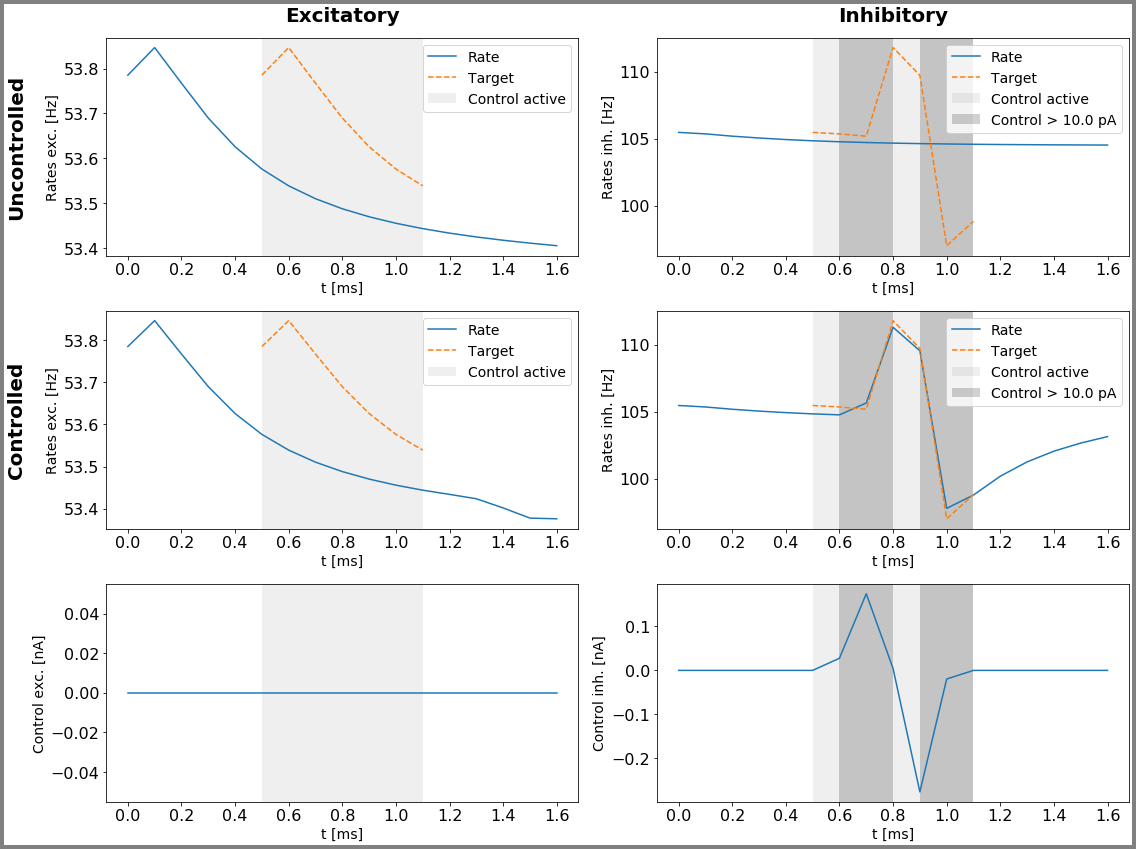

In [296]:
cost.setParams(1.0, 0., 2.0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 30
alg = "A1"
case = "A"

control0 = aln.getZeroControl()
control1 = bestControlA

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

print(grad)

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)

True 3
RUN  0 , total integrated cost:  8.472568532657641
RUN  1 , total integrated cost:  4.327796275666552
RUN  2 , total integrated cost:  2.1542727815337503
RUN  3 , total integrated cost:  1.606694384270155
RUN  4 , total integrated cost:  1.2248849628441556
RUN  5 , total integrated cost:  1.1485358201049798
RUN  6 , total integrated cost:  1.1450444190470614
RUN  7 , total integrated cost:  1.1444254270029846
RUN  8 , total integrated cost:  1.1442911474774062
RUN  9 , total integrated cost:  1.1442524317586749
RUN  10 , total integrated cost:  1.1442471073581002
RUN  11 , total integrated cost:  1.1442454105562327
RUN  12 , total integrated cost:  1.1442447968505816
RUN  13 , total integrated cost:  1.1442445402554253
RUN  14 , total integrated cost:  1.1442444988048073
RUN  15 , total integrated cost:  1.144244498803757
RUN  16 , total integrated cost:  1.1442444100558522
RUN  17 , total integrated cost:  1.144244328706091
RUN  18 , total integrated cost:  1.144244254753833
RU

ERROR:root:Problem in initial value trasfer



RUN  31 , total integrated cost:  1.1442436410259322
Improved over  31  iterations by  87  percent.
Problem in initial value trasfer:  Vmean_exc -56.70425182694073 -56.70423241486317
[[[ 0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.        ]
  [ 0.          0.          0.          0.          0.
    0.          0.10713243  0.90441522  0.01918399 -1.39523923
   -0.07005388  0.          0.          0.          0.
    0.          0.        ]]]


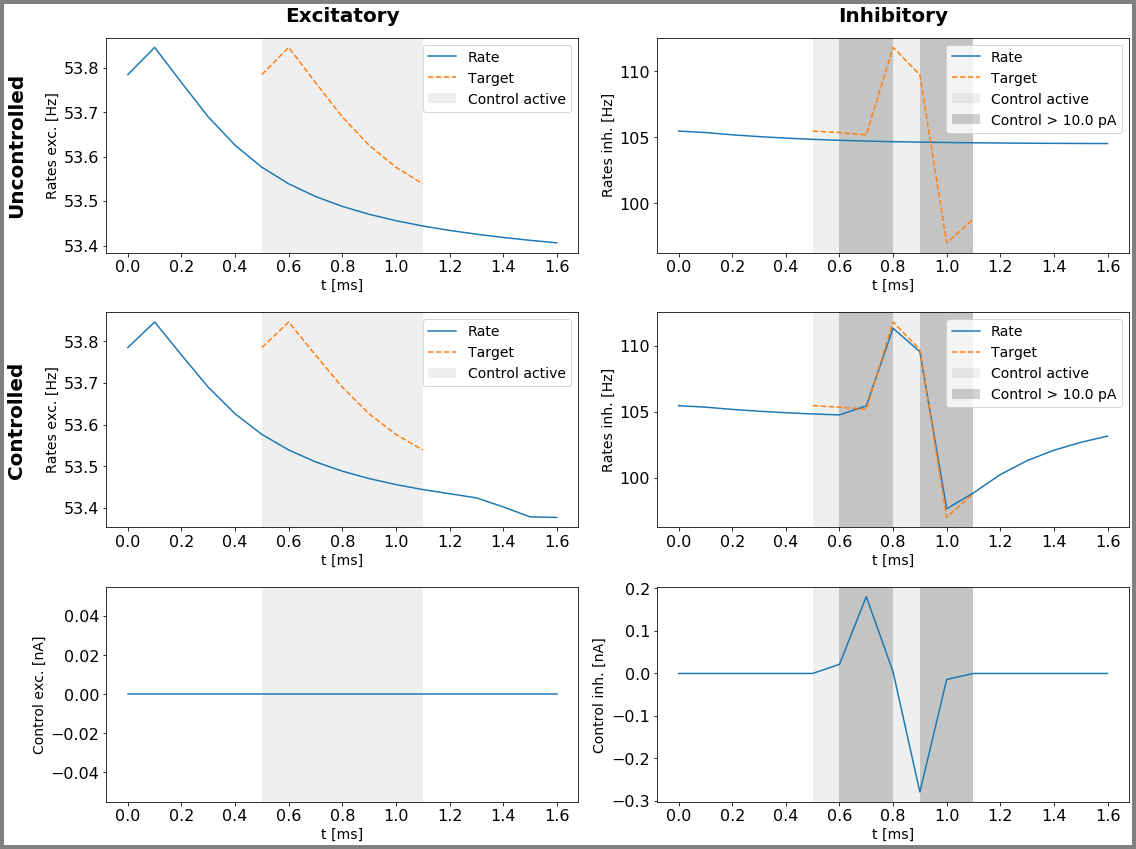

In [298]:
setinitvars(high_state_vars)
max_it = 40
alg = "A2"
case = "A"

control0 = aln.getZeroControl()
control1 = bestControlA2

bestControlA2, bestStateA2, costA2, runtimeA2 = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

print(bestControlA2)

for i in range(1, len(costA2)):
    if costA2[i-1] < costA2[i]:
        print("ERROR ---------------- in index ", i)

[[[ 0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.
    0.          0.        ]
  [ 0.          0.          0.          0.          0.
    0.         -0.03074659  0.03412818 -0.0021944  -0.01598527
    0.02781654  0.          0.          0.          0.
    0.          0.        ]]]


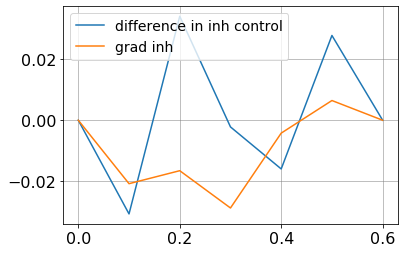

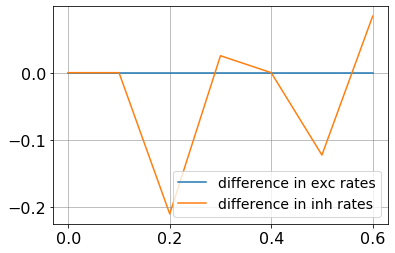

In [299]:
diff = bestControlA2 - bestControlA
diff_state = bestStateA2 - bestStateA

diff[:,:,0] = 0
diff[:,:,-1] = 0

print(diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc control")
plt.plot(t, diff[0,1,5:12], label="difference in inh control")
#plt.plot(t, - 1e0 * grad[0,0,:], label="grad exc")
plt.plot(t, - 1e-2 * grad[0,1,:], label="grad inh")
plt.legend()
plt.grid()
plt.show()

plt.plot(t, diff_state[0,0,5:12], label="difference in exc rates")
plt.plot(t, diff_state[0,1,5:12], label="difference in inh rates")
plt.legend()
plt.grid()
plt.show()